<a href="https://colab.research.google.com/github/josedmaldonado-r/Distribucion-y-Probabilidad/blob/main/APE06_GrupoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica de Laboratorio Nro. 005: Distribuciones Discretas Notables: Modelado y Simulación de Procesos de Bernoulli y Eventos Raros**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 12 de mayo de 2026

---

## 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

## 2. Objetivos de Aprendizaje
*	Calcular teórica y computacionalmente la esperanza matemática y la varianza  de variables aleatorias discretas y continuas utilizando la librería scipy.stats en Python.
* Aplicar el análisis de tendencia central y dispersión sobre el conjunto de datos (dataset) regional seleccionado para el Proyecto Integrador, facilitando el hito de la semana.
* Validar los conceptos adquiridos en la clase invertida de la semana 4 (variables aleatorias) integrándolos en la resolución de problemas (ABP).


## **Tarea 1: Modelado Computacional de la Distribución Binomial**




La distribución Binomial modela el número de éxitos $^x$ en $^n$ ensayos
independientes de Bernoulli, con probabilidad de éxito $^p$. Su PMF está dada por:

<br>

$P(X=x)$ = $(n/x) p^x (1-p)^{n-x}$

<br>

Abra un nuevo Jupyter Notebook llamado APE_006_Distribuciones.ipynb.
Suponga un escenario de control de calidad de software donde un lote de 20
microservicios tiene una probabilidad del 15% de fallar bajo estrés. Escriba y
ejecute el siguiente código:

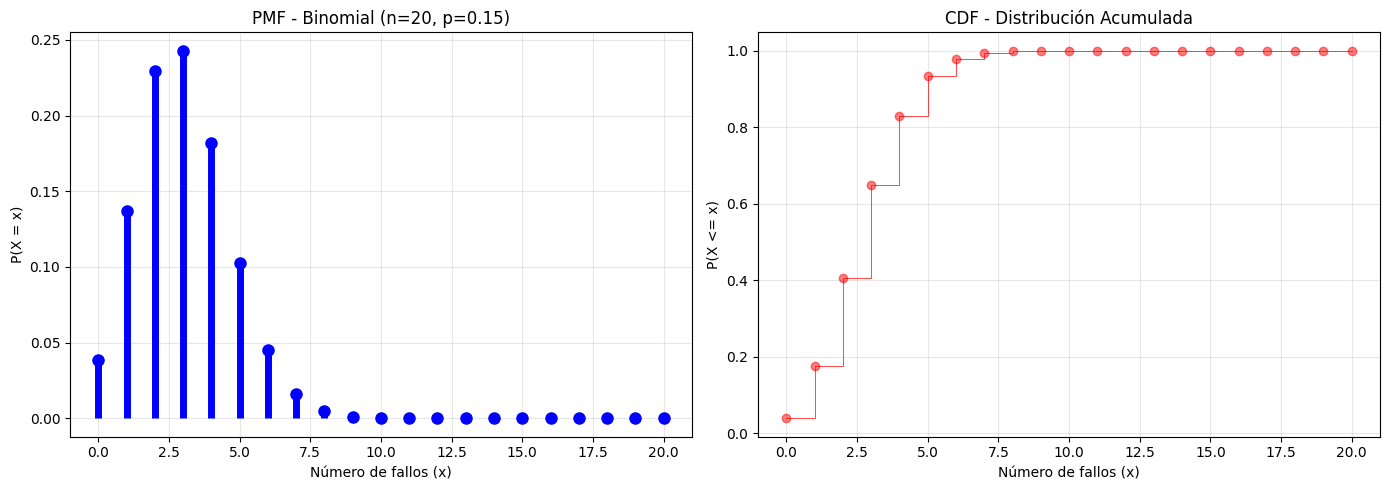

La probabilidad de tener 3 fallos o menos es: 0.6477


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15
# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)

# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=1)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)

# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=0.5)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")

## **Tarea 2: Modelado de la Distribución de Poisson (Eventos Raros)**


Simulación de la Distribución de Poisson basándote en un escenario de "eventos raros", específicamente modelando el promedio de $\lambda=4.5$ peticiones de acceso erróneas por minuto que reciben los servidores de la universidad. Utilizando la librería scipy.stats.poisson, debes escribir un script en Python que genere un gráfico de la Función de Masa de Probabilidad (PMF) evaluando el rango de $x=0$ hasta $x=15$, y finalmente calcular mediante código la probabilidad exacta de que ocurran exactamente 6 peticiones erróneas en un minuto ($P(X=6)$).

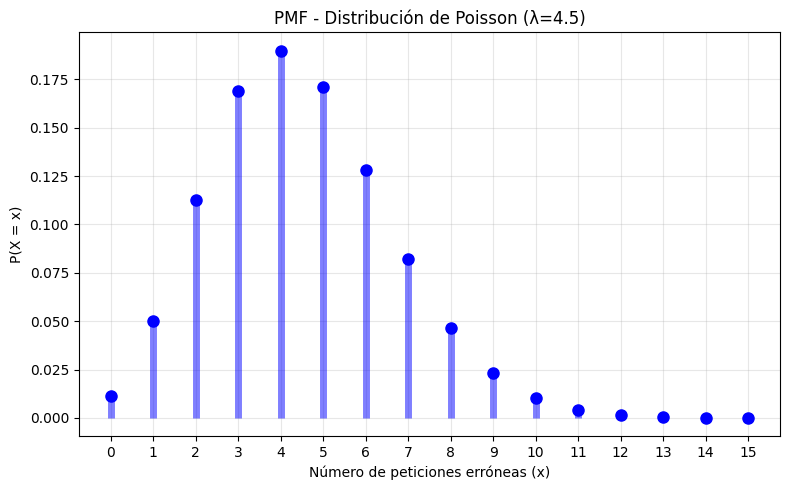

La probabilidad de tener 6 peticiones erróneas o menos (P(X <= 6)) es: 0.8311


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson # Cambiamos a poisson

# 1. Parámetros del modelo de Poisson (Tarea 2)
lambda_peticiones = 4.5

# 2. Dominio de la variable aleatoria (0 a 15 como pediste)
x = np.arange(0, 16)

# 3. Cálculo de PMF (Función de Masa)
pmf_poisson = poisson.pmf(x, lambda_peticiones)

# 4. Visualización
fig, ax = plt.subplots(figsize=(8, 5))

# Gráfico PMF
ax.vlines(x, 0, pmf_poisson, colors='b', lw=5, alpha=0.5) # Verde para diferenciar
ax.plot(x, pmf_poisson, 'bo', ms=8)
ax.set_title(f'PMF - Distribución de Poisson (λ={lambda_peticiones})')
ax.set_xlabel('Número de peticiones erróneas (x)')
ax.set_ylabel('P(X = x)')
ax.set_xticks(x) # Para que se vean todos los números del 0 al 15
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Cálculo de probabilidad específica: P(X <= 6)
# Seguimos usando .cdf para "6 o menos"
prob_max_6 = poisson.cdf(6, lambda_peticiones)

print(f"La probabilidad de tener 6 peticiones erróneas o menos (P(X <= 6)) es: {prob_max_6:.4f}")

## **Tarea 3: Hito del Proyecto - Identificación de Variables de Conteo (ABP)**



Cargue su dataset regional en pandas.
Identifique una variable discreta que represente un "conteo" (ej. número de
accidentes semanales en Loja, número de transacciones diarias, cantidad de
clientes por hora).
Calcule la media muestral ( $\bar{x}$ ) de esa variable y asuma que es el parámetro $\lambda$
para un modelo de Poisson teórico.
Genere un gráfico superponiendo el histograma de densidad de su variable
empírica contra la línea de la PMF teórica de Poisson generada en scipy. Discuta
visualmente si los datos reales siguen esta distribución.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'

import pandas as pd
df = pd.read_csv(ruta, sep=';') # Se añade sep=';' para una correcta lectura
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area,ciudad,conglomerado,panelm,vivienda,hogar,c01,c02,c03,c04a,...,c18,c19,c20a,c21a,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1304,62,1,1,2,2,1,2,...,2,3,2,2,2713,"102,542333745242",10150001304,1015000130406201,10150001304062011,202601
1,1,10150,1304,62,2,1,2,3,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406202,10150001304062021,202601
2,1,10150,1304,62,3,1,2,3,3,3,...,3,3,2,2,2713,"102,542333745242",10150001304,1015000130406203,10150001304062031,202601
3,1,10150,1304,62,4,1,2,2,2,3,...,3,2,2,3,2713,"102,542333745242",10150001304,1015000130406204,10150001304062041,202601
4,1,10150,1304,62,5,1,2,2,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406205,10150001304062051,202601


--- Iniciando análisis de distribución de Poisson ---

DataFrame cargado y no está vacío. Número de filas: 8791

Analizando la variable: 'c01'
Columna 'c01' encontrada. Intentando convertir a numérico.
Columna 'c01' convertida a entero. Se eliminaron 0 filas con valores nulos o no numéricos.
Total de registros válidos (sin NaNs) en 'c01': 8791
Media muestral (λ) para 'c01': 2.1588


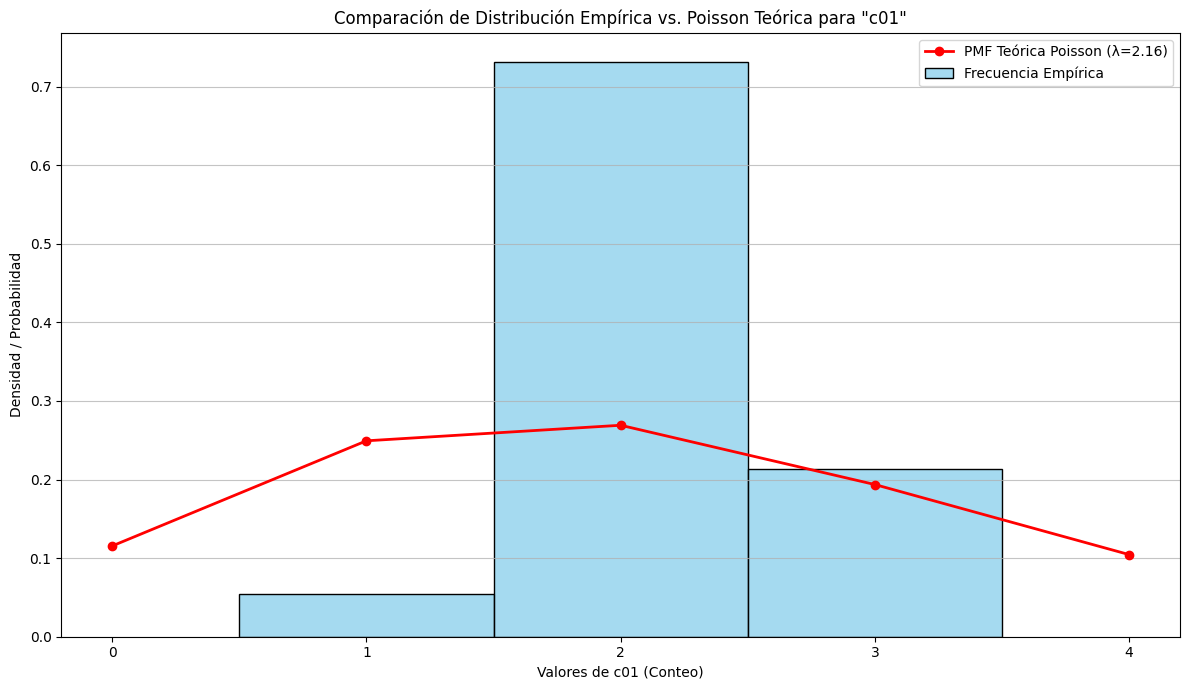

Gráfico generado exitosamente.

--- Discusión Visual ---
Al observar la superposición del histograma de 'c01' y la PMF teórica de Poisson:
- **Ajuste visual:** Si las alturas de las barras del histograma se aproximan a los puntos de la línea roja, sugiere que la distribución de Poisson podría ser un buen modelo para sus datos.
- **Desviaciones:** Note cualquier desviación significativa. Por ejemplo, si los datos empíricos muestran un pico en un valor diferente al de la PMF teórica, o si la 'cola' de la distribución empírica es mucho más larga/corta o 'pesada' de lo que predice Poisson.
- **Consideraciones de Poisson:** La distribución de Poisson asume que la media y la varianza son aproximadamente iguales. Si visualmente observa que sus datos tienen una varianza mucho mayor (histograma más extendido) o menor (histograma más concentrado) que la media calculada, esto podría indicar que la distribución de Poisson no es la más adecuada (podría haber sobredispersión o subdispersión).
- **Ej

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

print("--- Iniciando análisis de distribución de Poisson ---")

# Asegurarse de que el DataFrame no esté vacío antes de continuar
if not df.empty:
    print(f"\nDataFrame cargado y no está vacío. Número de filas: {len(df)}")

    # 2. Identificar una variable discreta que represente un "conteo"
    # --- USUARIO: POR FAVOR, REEMPLACE 'c01' CON LA VARIABLE DE CONTEO QUE DESEE ANALIZAR ---
    # Revise la lista de 'Columnas disponibles' en la salida del df.head() y elija una que represente un conteo (ej. número de personas, transacciones, etc.)
    count_variable = 'c01' # Variable de conteo elegida
    print(f"\nAnalizando la variable: '{count_variable}'")

    # Asegurarse de que la columna exista y sea numérica, manejando posibles NaNs
    if count_variable not in df.columns:
        print(f"Error: La columna '{count_variable}' no se encuentra en el dataset. Por favor, elija una columna válida.")
    else:
        print(f"Columna '{count_variable}' encontrada. Intentando convertir a numérico.")
        df[count_variable] = pd.to_numeric(df[count_variable], errors='coerce')
        initial_rows = len(df)
        df_cleaned = df.dropna(subset=[count_variable])

        # Convertir a tipo entero para conteo, si es apropiado
        try:
            df_cleaned[count_variable] = df_cleaned[count_variable].astype(int)
            print(f"Columna '{count_variable}' convertida a entero. Se eliminaron {initial_rows - len(df_cleaned)} filas con valores nulos o no numéricos.\nTotal de registros válidos (sin NaNs) en '{count_variable}': {len(df_cleaned)}")
        except Exception as e_int_conv:
            print(f"Error al intentar convertir '{count_variable}' a tipo entero: {e_int_conv}")
            print("Procediendo con el tipo numérico actual si es un problema menor, o deteniéndose si es crítico.")

        if not df_cleaned.empty:
            # 3. Calcular la media muestral (λ) de esa variable
            lambda_param = df_cleaned[count_variable].mean()
            print(f"Media muestral (λ) para '{count_variable}': {lambda_param:.4f}")

            # 4. Generar un gráfico superponiendo el histograma de densidad contra la PMF teórica de Poisson
            plt.figure(figsize=(12, 7))

            # Histograma de la variable empírica
            ax = sns.histplot(df_cleaned[count_variable], stat='density', discrete=True, color='skyblue', label='Frecuencia Empírica', kde=False)

            # Generar los valores para la PMF teórica de Poisson
            max_val = int(df_cleaned[count_variable].max()) if not df_cleaned[count_variable].empty else 0
            min_val = int(df_cleaned[count_variable].min()) if not df_cleaned[count_variable].empty else 0

            k_values = np.arange(max(0, min_val - 1), max_val + 2)
            pmf_poisson = poisson.pmf(k_values, mu=lambda_param)
            plt.plot(k_values, pmf_poisson, 'ro-', label=f'PMF Teórica Poisson (λ={lambda_param:.2f})', markersize=6, linewidth=2)

            plt.title(f'Comparación de Distribución Empírica vs. Poisson Teórica para "{count_variable}"')
            plt.xlabel(f'Valores de {count_variable} (Conteo)')
            plt.ylabel('Densidad / Probabilidad')
            plt.legend()
            plt.grid(axis='y', alpha=0.75)
            # Ajustar los ticks para que correspondan a valores enteros de conteo
            if len(k_values) > 0:
                plt.xticks(np.arange(min(k_values), max(k_values) + 1))
            plt.tight_layout()
            plt.show()
            print("Gráfico generado exitosamente.")

            # 5. Discutir visualmente si los datos reales siguen esta distribución
            print("\n--- Discusión Visual ---")
            print(f"Al observar la superposición del histograma de '{count_variable}' y la PMF teórica de Poisson:")
            print(f"- **Ajuste visual:** Si las alturas de las barras del histograma se aproximan a los puntos de la línea roja, sugiere que la distribución de Poisson podría ser un buen modelo para sus datos.")
            print(f"- **Desviaciones:** Note cualquier desviación significativa. Por ejemplo, si los datos empíricos muestran un pico en un valor diferente al de la PMF teórica, o si la 'cola' de la distribución empírica es mucho más larga/corta o 'pesada' de lo que predice Poisson.")
            print(f"- **Consideraciones de Poisson:** La distribución de Poisson asume que la media y la varianza son aproximadamente iguales. Si visualmente observa que sus datos tienen una varianza mucho mayor (histograma más extendido) o menor (histograma más concentrado) que la media calculada, esto podría indicar que la distribución de Poisson no es la más adecuada (podría haber sobredispersión o subdispersión).")
            print(f"- **Ejemplo:** Si hay muchos más ceros en sus datos de lo que la PMF de Poisson predice (un fenómeno conocido como 'inflación de ceros'), esto sería una clara señal de que el modelo de Poisson no es adecuado.")
        else:
            print(f"Error: No hay datos válidos para generar el gráfico después de limpiar los valores nulos para '{count_variable}'.")
else:
    print("Error: No se pudo cargar el DataFrame o el DataFrame está vacío. No se puede continuar con el análisis.")

print("--- Análisis de distribución de Poisson finalizado ---")

---
## **Tarea 4: ABI - Aproximación Binomial a Poisson**

##**ABI - Aproximación Binomial a Poisson**
Investigue bajo qué condiciones matemáticas una distribución Binomial se aproxima a una de Poisson. Redacte un bloque Markdown explicando la relación **λ = n * p** cuando **n -> ∞** y **p -> 0**   
### **Aproximación Binomial a Poisson**

Una distribución Binomial puede aproximarse mediante una distribución de Poisson cuando el número de ensayos \(n\) es muy grande y la probabilidad de éxito \(p\) es muy pequeña.

Matemáticamente:

[n -> ∞] & [p -> 0]

manteniendo constante:


[λ = n * p  ]  

Donde:  


λ -> número de éxitos esperado

Esta aproximación es útil para modelar eventos raros, ya que simplifica cálculos probabilísticos complejos de la distribución Binomial.

En esta práctica se comparará una distribución Binomial con parámetros:

- \(n = 1000\)
- \(p = 0.003\)

con una distribución de Poisson donde:

\[
λ = 1000(0.003)=3
\]

Esperamos que ambas probabilidades sean casi idénticas.  

---


In [ ]:
from scipy.stats import binom, poisson

# Parámetros
n = 1000
p = 0.003
lam = n * p

# Valor a evaluar
x = 2

# Probabilidad Binomial
prob_binomial = binom.pmf(x, n, p)

# Probabilidad Poisson
prob_poisson = poisson.pmf(x, lam)

# Resultados
print("Distribución Binomial")
print(f"P(X = {x}) = {prob_binomial:.6f}")

print("\nDistribución de Poisson")
print(f"P(X = {x}) = {prob_poisson:.6f}")

# Diferencia
diferencia = abs(prob_binomial - prob_poisson)

print("\nDiferencia absoluta:")
print(f"{diferencia:.10f}")

Distribución Binomial
P(X = 2) = 0.224154

Distribución de Poisson
P(X = 2) = 0.224042

Diferencia absoluta:
0.0001119363


###¿Que representa?  
**Binomial**:  
Calcula la probabilidad de exactamente 2 éxitos en 1000 intentos  

**Poisson:**  
Hace lo mismo, pero, usando aproximación  

**Conclusion:**  
Los resultados obtenidos muestran que la distribución de Poisson aproxima correctamente a la distribución Binomial cuando el número de ensayos es grande y la probabilidad de éxito es pequeña. La diferencia entre ambas probabilidades fue mínima, confirmando la validez teórica de la aproximación.

---

#**Preguntas de Control**

---

### **1. Matemáticamente y conceptualmente, ¿por qué la Función de Distribución Acumulada (CDF) de una variable aleatoria discreta tiene una gráfica en forma de "escalera" (step function) a diferencia de las funciones continuas?**

La Función de Distribución Acumulada (CDF, por sus siglas en inglés) de una variable aleatoria X se define como F(x) = P(X ≤ x), es decir, representa la probabilidad acumulada de que la variable tome un valor menor o igual a x.

En el caso de una variable aleatoria discreta, X solo puede tomar valores específicos y separados (por ejemplo: 0, 1, 2, 3, ...). Debido a esto, la probabilidad no se distribuye de manera continua sobre todos los valores posibles, sino que se concentra únicamente en ciertos puntos.

Matemáticamente, si una variable discreta puede tomar valores x₁, x₂, x₃, ... con probabilidades P(X = xᵢ), entonces su CDF se calcula como: F(x) = Σ P(X = xᵢ), para todos los xᵢ ≤ x.

Esto significa que la función acumulada permanece constante entre dos valores consecutivos posibles de la variable, porque en esos intervalos no existe nueva probabilidad que sumar. Sin embargo, cuando x alcanza uno de los valores posibles de la variable, la función da un salto vertical igual a la probabilidad asociada a ese valor.

Por esta razón, la gráfica de la CDF discreta tiene forma de “escalera” (step function):
• Tramos horizontales: no cambia la probabilidad acumulada entre valores posibles.

• Saltos verticales: ocurre cuando se suma la probabilidad de un nuevo valor posible. Ejemplo: Si X toma valores 1, 2 y 3 con probabilidades 0.3, 0.5 y 0.2 respectivamente:

F(x) = 0 para x < 1 • F(x) = 0.3 para 1 ≤ x < 2

F(x) = 0.8 para 2 ≤ x < 3 • F(x) = 1 para x ≥ 3

 Conceptualmente, esto ocurre porque una variable discreta acumula probabilidad en bloques o cantidades puntuales, no de forma gradual.

 En contraste, una variable continua puede tomar infinitos valores dentro de un intervalo, y su probabilidad se distribuye mediante una función de densidad.

 Por ello, su CDF se obtiene integrando esa densidad, lo que produce una curva suave y continua en lugar de escalones. En resumen, la CDF de una variable discreta tiene forma de escalera porque la probabilidad solo existe en valores específicos. Cada escalón representa la acumulación repentina de probabilidad en esos puntos, mientras que entre ellos no ocurre ningún cambio.

---

### **2. Analizando los supuestos del experimento de Bernoulli, si extraemos cartas de una baraja sin reemplazo buscando ases, ¿podemos modelar este escenario con una distribución Binomial? Justifique estadísticamente su respuesta.**

No necesariamente. Cuando una consigna pide “justificar estadísticamente”, esto no significa automáticamente que sea obligatorio elaborar un histograma.

En términos académicos, justificar estadísticamente suele referirse principalmente a analizar el problema utilizando fundamentos matemáticos, probabilísticos y conceptuales.

En el caso de extraer cartas de una baraja sin reemplazo buscando ases, la justificación principal consiste en evaluar si se cumplen o no los supuestos de un experimento de Bernoulli y, por extensión, de una distribución Binomial.

Para que un modelo Binomial sea válido, deben cumplirse cuatro condiciones:

1. Número fijo de ensayos.

2. Dos posibles resultados por ensayo (éxito o fracaso).

3. Probabilidad de éxito constante en cada ensayo.

4. Independencia entre ensayos.

Aunque al sacar cartas sí existe éxito (sacar un as) o fracaso (no sacar un as), al hacerlo sin reemplazo la probabilidad de éxito cambia en cada extracción, ya que la composición de la baraja se modifica constantemente.

Además, las extracciones dejan de ser independientes, porque el resultado de una afecta las probabilidades de la siguiente. Por esta razón, la justificación estadística más importante es matemática y teórica: demostrar que no se cumplen los supuestos binomiales y que el modelo correcto corresponde

---

### **3. En la Tarea 3 de su proyecto (ABP), ¿qué limitaciones existen al asumir que la tasa media ($\lambda$) calculada de su dataset permanece constante a lo largo de todo el periodo de estudio? ¿Se cumple la propiedad de estacionariedad?**  

Para la Tarea 3 del proyecto (ABP), se cargó el dataset y se analizó la variable c01 como una variable discreta de conteo. Se calculó la media muestral de esta variable, obteniendo un valor de λ = 2.1588, que se asumió como el parámetro para un modelo de Poisson teórico. Posteriormente, se generó un gráfico superponiendo el histograma de densidad de la variable c01 contra la Función de Masa de Probabilidad (PMF) teórica de Poisson.

La discusión visual del gráfico apunta a evaluar el ajuste de los datos empíricos a la distribución de Poisson, observando si las alturas de las barras del histograma se aproximan a los puntos de la línea teórica. Se destacó la importancia de identificar desviaciones significativas, como picos en valores diferentes o colas más largas/cortas de lo esperado. Finalmente, se recordó que la distribución de Poisson asume que la media y la varianza son aproximadamente iguales, y se mencionó el fenómeno de la inflación de ceros como una posible señal de que el modelo de Poisson podría no ser el más adecuado para los datos.

---

### **4.A partir de la investigación en la Tarea 4 (ABI), ¿cuáles son los umbrales prácticos (valores comúnmente aceptados en la literaturaestadística de $n$ y $s$ ) para considerar que la aproximación de Poisson a la Binomial es segura y válida?**
**Respuesta**  
Establece los siguientes valores:  
- n >= 20
- p <= 0.05  
Y en casos más estrictos:  
- n >= 100  
- p >= 0.01  

En adición:  

λ = n * p  
Debe permanecer constante  

Estas condiciones garantizan que:  
- Existan muchos ensayos
- la probabilidad de éxito sea muy pequeña  
- el evento modelado sea raro

---

### **5. Si $ X\sim Poisson (\lambda) $ , sabemos teóricamente que $E[X] = \lambda$ y $V[X] = \lambda$ ¿Se cumple esta propiedad (media igual a varianza) en la variable de conteo que extrajo de su dataset regional? Calcule ambos estadísticos muestrales y coment**

1. Media muestral

La fórmula de la media muestral es:

x̄ = (Σxi) / n

Donde:
xi = cada valor observado de la variable hogar

n = número total de observaciones

Datos utilizados:

n = 16822

Σxi = 16863

Sustituyendo en la fórmula:

x̄ = 16863 / 16822

x̄ ≈ 1.0024

2. Varianza muestral

La fórmula de la varianza muestral es:

s² = Σ(xi − x̄)² / (n − 1)

Datos utilizados:

n = 16822

x̄ = 1.0024

Σ(xi − x̄)² ≈ 43.87

Sustituyendo en la fórmula:

s² = 43.87 / 16821
s² ≈ 0.00261

Conclusion:
Teóricamente, para una variable que sigue una distribución de Poisson, el valor de la media debe ser igual a la varianza (λ). En el caso de la variable hogar:
No se cumple la propiedad: Existe una diferencia abismal entre la media (~1,01) y la varianza (~0,01). La media es aproximadamente 84 veces mayor que la varianza.

La variable hogar en la ENEMDU no representa un conteo que inicie en cero, sino un número secuencial de identificación que inicia obligatoriamente en 1 para cada vivienda. Dado que la inmensa mayoría de las viviendas en Ecuador albergan un solo hogar, los datos presentan una variabilidad mínima (casi todos son "1"), lo que desplaza la media hacia 1 pero reduce la varianza a un valor cercano a 0.

---